# Config

In [1]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
import pathlib
import ml_collections
import pandas as pd

OUT_DIR = pathlib.Path("C:\\Users\\pol12\\Desktop\\Universitat\\MAMME\\TFM\\tfm-ecoRL\\output")

In [2]:
def plot_with_rolling_mean_and_regression(
    df, x, y, window_size=10, title="Title of the graph", xlabel=None, ylabel=None,
    plot_size=(14, 7), grid=True, regression_line=True, alpha=0.3, rolling_mean_alpha=0.4,
    rolling_mean_color="blue", regression_line_style="--", regression_line_color="orange"
):
    """
    Plots a graph with the original data, rolling mean, and an optional regression line.

    Parameters:
    ------------
    df : DataFrame
        DataFrame containing the data to be plotted.

    x : str
        The column name for the x-axis data.

    y : str
        The column name for the y-axis data.

    window_size : int, optional, default=10
        The window size for calculating the rolling mean.

    title : str, optional, default="Title of the graph"
        Title for the plot.

    xlabel : str, optional
        Label for the x-axis. Defaults to the name of the x column.

    ylabel : str, optional
        Label for the y-axis. Defaults to the name of the y column.

    plot_size : tuple, optional, default=(14, 7)
        Size of the plot in inches (width, height).

    grid : bool, optional, default=True
        Whether to display the grid on the plot.

    regression_line : bool, optional, default=True
        Whether to include a linear regression line.

    alpha : float, optional, default=0.3
        Transparency for the original data points.

    rolling_mean_alpha : float, optional, default=0.4
        Transparency for the rolling mean line.

    rolling_mean_color : str, optional, default="blue"
        Color of the rolling mean line.

    regression_line_style : str, optional, default="--"
        Line style for the regression line.

    regression_line_color : str, optional, default="orange"
        Color of the regression line.
    """
    # Drop NaN values for x and y
    df = df.dropna(subset=[x, y])

    # Sort the DataFrame by the x column
    df = df.sort_values(by=x)

    # Calculate the rolling mean with the specified window size
    df["Rolling_Mean"] = df[y].rolling(window=window_size).mean()

    # Prepare for regression
    x_regression = np.array(pd.to_numeric(df[x]))
    y_regression = df[y].values
    mask = ~np.isnan(x_regression) & ~np.isnan(y_regression)  # Remove NaN values for regression
    x_regression = x_regression[mask]
    y_regression = y_regression[mask]

    # Perform linear regression
    if regression_line:
        slope, intercept = np.polyfit(x_regression, y_regression, 1)
        regression_line_values = slope * x_regression + intercept

    # Plot
    fig, ax = plt.subplots(figsize=plot_size)

    # Plot the original data points with transparency
    ax.plot(df[x], df[y], "-", alpha=alpha, label="Original Data")

    # Plot the rolling mean
    ax.plot(
        df[x],
        df["Rolling_Mean"],
        label=f"Rolling Mean (window={window_size})",
        color=rolling_mean_color,
        alpha=rolling_mean_alpha,
        linewidth=2,
    )

    # Plot the regression line if enabled
    if regression_line:
        ax.plot(
            df[x],
            regression_line_values,
            label="Regression Line",
            linestyle=regression_line_style,
            color=regression_line_color,
            linewidth=2,
        )

    # Customize labels and title
    ax.set_xlabel(xlabel if xlabel else x)
    ax.set_ylabel(ylabel if ylabel else y)
    ax.set_title(title, fontweight="bold", fontsize=16)

    # Add a legend
    ax.legend()

    # Show the grid if specified
    if grid:
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, color="gray", alpha=0.2)

    # Display the plot
    plt.show()

"""
#We build dataframe (UNCOMMENT FOR NOTEBOOK VISUALIZATION)
import numpy as np
x_data = np.linspace(-4, 4, 100) #set x values we will plot
y_data = np.sin(np.linspace(-4, 4, 100)) #set y values we will plot
df = pd.DataFrame({"time_variable": x_data, "plot_variable": y_data})
"""

'\n#We build dataframe (UNCOMMENT FOR NOTEBOOK VISUALIZATION)\nimport numpy as np\nx_data = np.linspace(-4, 4, 100) #set x values we will plot\ny_data = np.sin(np.linspace(-4, 4, 100)) #set y values we will plot\ndf = pd.DataFrame({"time_variable": x_data, "plot_variable": y_data})\n'

In [15]:
#@title Eval Config
eval_config = ml_collections.ConfigDict()

eval_config.phase = 'eval'

eval_config.num_workers = 0
eval_config.num_evaluators = 1

# Saving
eval_config.path = OUT_DIR / "bandit_models" / "dependent_e.pkl" # "independent", "dependent_{u,e,m,h}"
eval_config.params_filename = eval_config.path.stem

# Evaluation
eval_config.random_seed = 42
eval_config.num_eval_episodes = 400
eval_config.log_dynamics = True

# Evaluation environment
eval_config.eval_environment = ml_collections.ConfigDict()
eval_config.eval_environment.env_name = "bandit_eval"
eval_config.eval_environment.steps_per_episode = int(100)
eval_config.eval_environment.reward_structure = "dependent_e" # "independent", "dependent_{u,e,m,h}"

# Agent
eval_config.agent = ml_collections.ConfigDict()

# json.loads(eval_config.to_json_best_effort())

In [16]:
from bandits.bandit_environments import create_env
from bandits.agents_2 import create_agent

# Load trained agent
with open(eval_config.path, 'rb') as fp:
    training_results = pickle.load(fp)

params = training_results[0]['params']
training_config = training_results[0]['config']
agent_config = training_config['agent']
training_df = training_results[0]['training_df']

# Initialize evaluation environment.
eval_env = create_env(eval_config.eval_environment)
observation = eval_env.reset() #[0,0,0]

# Initialize agent (same as training) and set learning rate to 0
agent = create_agent(
    agent_config=agent_config,
    observation=observation,
    num_actions=eval_env.num_actions,
)

# Setup initial LSTM memory state.
initial_lstm_state = agent.get_initial_lstm_state()
lstm_state = initial_lstm_state

# Overwrite agent paramters with saved training parameters.
agent.params = params

# Training Evaluation

In [17]:
#@title Training Config
training_config

{'agent': {'e_loss_coef_end': 0.0,
  'e_loss_coef_start': 1.0,
  'gamma': 0.9,
  'global_norm_grad_clip': 50.0,
  'learning_rate_end': 0.0,
  'learning_rate_start': 0.0003,
  'max_unroll_steps': 200,
  'num_lstm_units': 48,
  'random_seed': 42,
  'total_training_steps': 2000000,
  'v_loss_coef': 0.05},
 'environment': {'env_name': 'bandit',
  'reward_structure': 'dependent_e',
  'steps_per_episode': 100},
 'eval_every_steps': 200000,
 'log_every_steps': 200,
 'num_eval_episodes': 400,
 'num_evaluators': 1,
 'num_workers': 1,
 'params_filename': 'my_trained_agent_independent_arms',
 'path': './',
 'phase': 'train',
 'random_seed': 42}

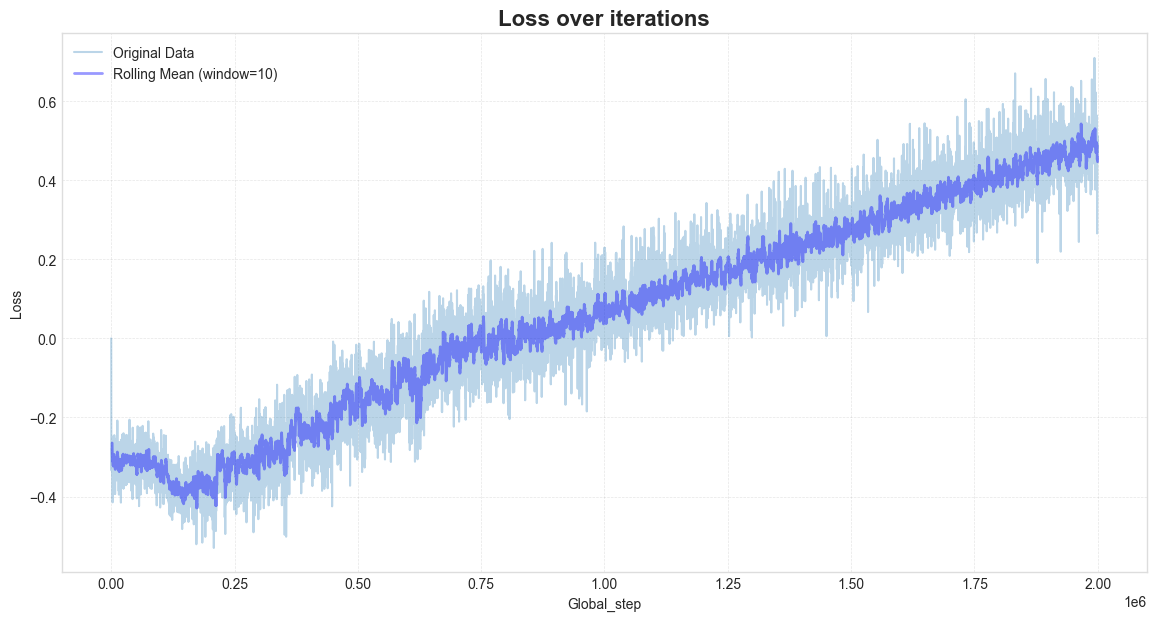

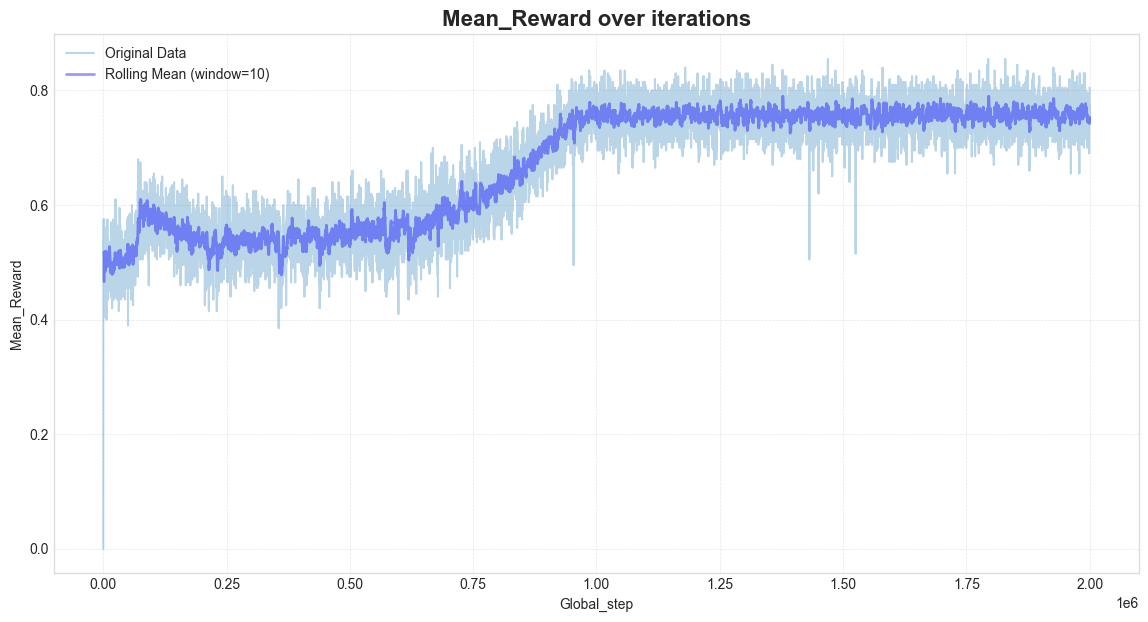

In [21]:
plot_with_rolling_mean_and_regression(training_df, x="Global_step", y="Loss", regression_line=False, title="Loss over iterations")
plt.show()
plot_with_rolling_mean_and_regression(training_df, x="Global_step", y="Mean_Reward", regression_line=False, title="Mean_Reward over iterations")
plt.show()

# Testing Evaluation

In [18]:
from bandits.evaluation import evaluate_all_probs, evaluate_mean_cum_regret, plot_data_with_uncertainty

eval_actions, eval_regrets, cumulative_regrets = evaluate_all_probs(eval_env, agent, initial_lstm_state, verbose=False)
print("evaluate_all_probs evaluated!")

eval_actions_cum_regret, eval_regrets_cum_regret, cumulative_regrets_cum_regret, mean_cumulative_regret, std_cumulative_regret, se_cumulative_regret = evaluate_mean_cum_regret(eval_env, agent, eval_config.num_eval_episodes, initial_lstm_state, verbose=False)

Done evaluation.
evaluate_all_probs evaluated!
Done evaluation.


<Axes: title={'center': 'Testing: Independent'}, xlabel='Trial #', ylabel='Cumulative Regret'>

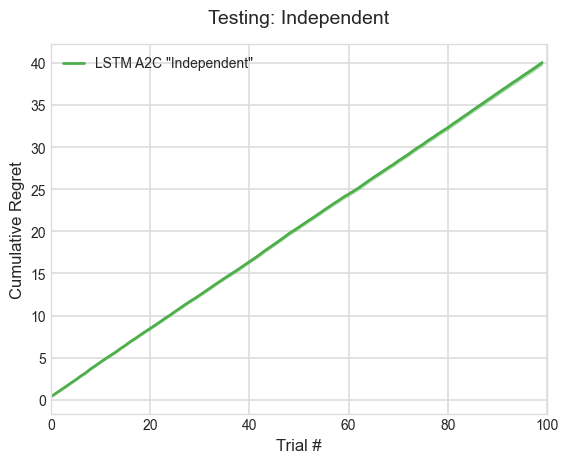

In [19]:
plot_data_with_uncertainty(np.arange(0, len(mean_cumulative_regret)), mean_cumulative_regret, std_cumulative_regret, se_cumulative_regret)

In [15]:
results_mean_cum_regret = {}
for env_type in ["independent", "dependent_u", "dependent_e", "dependent_m", "dependent_h"]:
    eval_env._reward_structure = env_type
    results_mean_cum_regret[env_type] = evaluate_mean_cum_regret(eval_env, agent, eval_config.num_eval_episodes, initial_lstm_state=initial_lstm_state, verbose=False)
    print(f"{env_type} evaluated \n")

color = ["#4daf4a", "#555555", "#888888", "#bbbbbb"]

# mean_cumulative_regret, std_cumulative_regret, se_cumulative_regret = results_mean_cum_regret["independent"]
for env_type in ["independent", "dependent_u", "dependent_e", "dependent_m", "dependent_h"]:
    eval_act, eval_reg, cum_reg, mean_cum_reg, std_cum_reg, se_cum_reg = results_mean_cum_regret[env_type]
    plot_data_with_uncertainty(np.arange(0, len(mean_cum_reg)), mean_cum_reg, std_cum_reg, se_cum_reg, label=env_type, color=color[i])


KeyboardInterrupt: 

# 4.Visualization

In [10]:
# Auxiliary functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_action_results(data, env, tick_fontsize=16, label_fontsize=20):
    """Plot heatmap of action results"""
    # Setup custom legend.
    cmap_name = 'tab20c'
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    zero_color = cmap(0.)
    one_color = cmap(1.)
    patch1 = mpatches.Patch(color=zero_color, label='Arm 1')
    patch2 = mpatches.Patch(color=one_color, label='Arm 2')

    # Setup evaluation episodes to test the agent on.
    arm1_probs = np.arange(101)/100
    arm2_probs = 1. - arm1_probs

    num_episodes = len(arm1_probs)
    eval_episodes = np.arange(num_episodes)

    # Set yticks labels
    ytick_vals = [0, eval_episodes[int(len(eval_episodes)/2)], eval_episodes[-1]]
    ytick_labels = []
    for i in ytick_vals:
        cur_probs = str(int(arm1_probs[i]*100)) + ", " + str(int(arm2_probs[i]*100))
        ytick_labels.append(cur_probs)

    # Build plot
    fig = plt.figure(figsize=(8, 6))
    ax = plt.subplot()
    plt.imshow(data, cmap='tab20c', origin='lower')
    plt.yticks(
        ticks=ytick_vals,
        labels=ytick_labels,
        fontsize=tick_fontsize,
        )
    plt.xticks(
        ticks=[0, env._steps_per_episode],
        labels=[0, env._steps_per_episode],
        fontsize=tick_fontsize,
        )
    plt.xlabel("Trials", fontsize=label_fontsize)
    plt.ylabel("Arm win probabilities \n (Arm 1 %, Arm 2 %)", fontsize=label_fontsize)
    ax.spines[['right', 'top']].set_visible(False)
    plt.legend(handles=[patch1, patch2],
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              frameon=False,
              fontsize=label_fontsize,
              borderaxespad=0.,
              )
    plt.tight_layout()
    plt.show()

def plot_all_cum_regret(df, alpha=0.7):
    # 1. Set the specific aesthetic
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Liberation Sans"],
        "axes.edgecolor": "#DDDDDD",
        "grid.color": "#DDDDDD",
        "grid.linewidth": 1.2
    })

    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

    # 2. Setup Gradient (RdBu as requested originally, or Viridis for clarity)
    norm = plt.Normalize(vmin=0, vmax=len(df)-1)
    sm = plt.cm.ScalarMappable(cmap='RdBu', norm=norm)

    # 3. Plotting
    for idx, row in df.iterrows():
        color = sm.to_rgba(idx)
        # We use a thinner line to match the high-density look of the reference
        ax.plot(row.values, color=color, alpha=alpha, linewidth=1.5)

    # 4. Replicating the Labels and Title from the image
    ax.set_title(r"$R_T(b)$ from Red (0,100) to Blue (100,0)", fontsize=14, fontweight='normal', pad=15)
    ax.set_xlabel("Trial #", fontsize=14)
    ax.set_ylabel("Cumulative Regret", fontsize=14)

    # 5. Formatting Ticks
    ax.tick_params(labelsize=14)
    ax.set_xlim(0, len(df.columns)) # Ensure it starts at 0 like the image

    # 6. The Legend/Colorbar
    # The image doesn't use a colorbar, it uses a legend.
    cbar = fig.colorbar(sm, ax=ax, aspect=30, pad=0.02)
    cbar.outline.set_visible(False)
    cbar.set_label('Row Index', size=12)

    for spine in ax.spines.values():
        spine.set_visible(True)

    plt.tight_layout()
    plt.show()


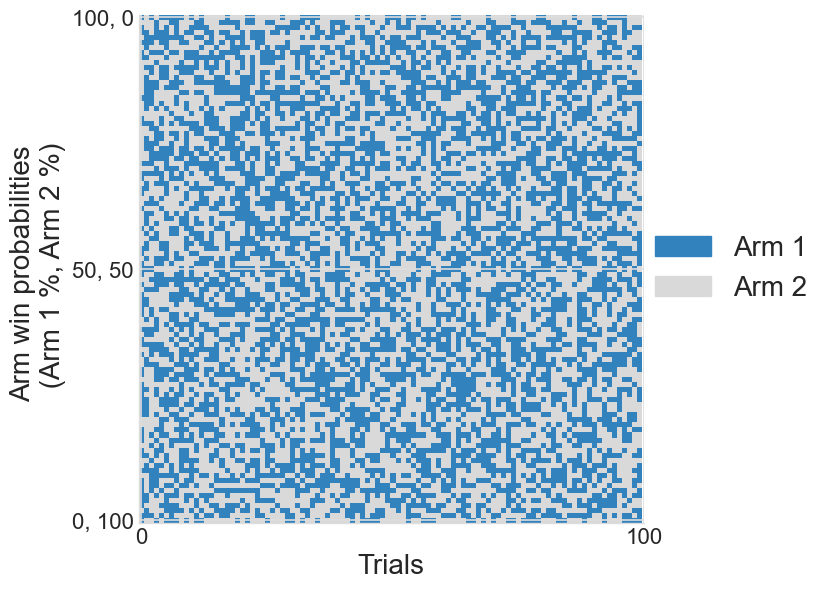

In [20]:
# Independent agent on Independent Eval env
plot_action_results(eval_actions, eval_env)

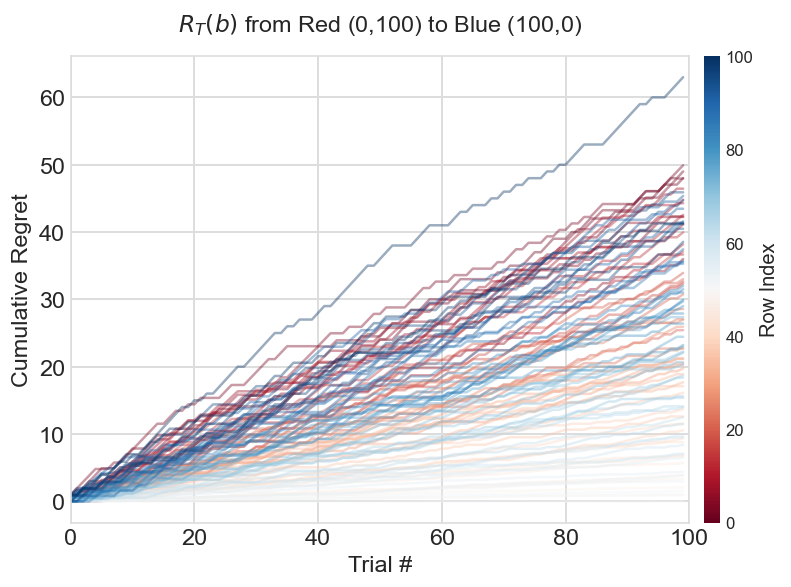

In [12]:
mean_cum_reg = pd.DataFrame(cumulative_regrets)

plot_all_cum_regret(mean_cum_reg, alpha=0.4)

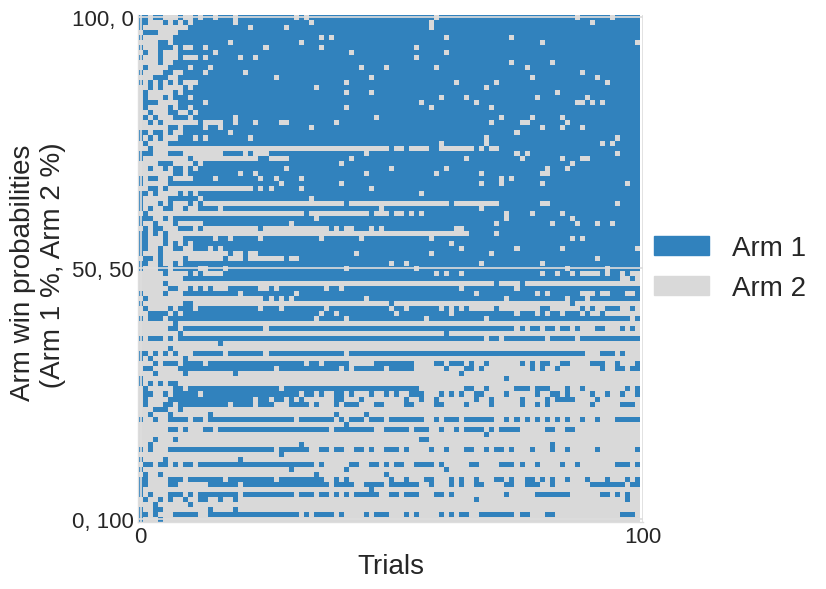

In [42]:
# Independent agent on Dependent Eval env
plot_action_results(eval_actions)